# GWT Hierarchical Expert-Cutpoint Comparison

This notebook is the self-contained workflow for the next observation-layer iteration on **Global Workspace Theory only**. It compares:

- baseline shared-`kappa` model
- wide-prior shared-`kappa` control
- hierarchical expert-cutpoint model

The scientific question is narrow: does strongly regularised expert-specific cutpoint shape help the identified GWT misfit **without** damaging the stance-level consciousness inference we care about?

## What We Check

- Posterior $P(C=1 \mid data)$ for Human / Chicken / LLMs / ELIZA
- Convergence diagnostics, including the new hierarchical expert-cutpoint parameters
- Stratified per-(expert, system) PPC using `pz1`:
  this is the existing leaf-updated diagnostic that localises bottom-layer misfit
- Stratified **tree-implied** PPC using `..._p`:
  this is a sidecar diagnostic using the upstream tree-implied indicator probabilities, **not** a prior-predictive or unconditional PPC
- Focus-cell summaries for the cells that mattered in notebook 13: Derek × Human / ELIZA and the middle-concentrated Chicken / LLM cells
- A short interpretation note with the explicit guardrail:
  Derek should not improve by simply making everyone else worse

## Why No Extra Pooled PPC?

Notebook 13 already showed that pooled per-expert PPC is confounded by system coverage. The relevant diagnostics for this iteration are the **stratified** PPCs and the focused bad-cell summaries, not another pooled histogram.

In [1]:
import os, sys, warnings
from pathlib import Path

os.environ["PYTENSOR_FLAGS"] = f"compiledir=/tmp/pytensor_cache_nb14_{os.getpid()}"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplcache")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/.cache")
warnings.filterwarnings("ignore", message="Loop fusion failed")

repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
notebook_dir = os.path.join(repo_root, "notebooks")
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

os.chdir(repo_root)

from gwt_hierarchical_cutpoints_analysis import (
    build_interpretation_note,
    focus_cell_comparison_table,
    plot_c_comparison,
    plot_stratified_ppc_suite,
    print_c_summary_table,
    print_diagnostics_table,
    print_ppc_metric_table,
    run_all,
)


## Run Configuration

The full run uses the intended long-run settings. The smoke cell below is optional and is useful if you want to confirm the notebook wiring before paying the compilation cost.

In [2]:
FULL_FIT_OVERRIDES = None
PPC_DRAWS = 500

SMOKE_FIT_OVERRIDES = {
    "NUM_SAMPLES": 120,
    "NUM_TUNE": 120,
    "NUM_CHAINS": 2,
}


In [3]:
# Optional smoke run:
# smoke_results = run_all(
#     fit_overrides=SMOKE_FIT_OVERRIDES,
#     ppc_draws=120,
#     save_figures=False,
#     verbose=True,
# )


## Main Fit

This is the main cell to run. It fits all three models and stores the results without plotting yet, so the notebook sections below stay organised.

In [4]:
results = run_all(
    fit_overrides=FULL_FIT_OVERRIDES,
    ppc_draws=PPC_DRAWS,
    save_figures=False,
    verbose=False,
)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [chicken__global_workspace_theory_C, 2024_leading_chat_llms__global_workspace_theory_C, a, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somato

Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 1124 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [chicken__global_workspace_theory_C, 2024_leading_chat_llms__global_workspace_theory_C, a, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic

Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 1167 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [chicken__global_workspace_theory_C, 2024_leading_chat_llms__global_workspace_theory_C, a, kappa_log_gap_loc, kappa_expert_gap_scale, kappa_expert_gap_offset, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_train

Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 619 seconds.


## Posterior C And Diagnostics

The diagnostics table includes the hierarchical expert-level parameters (`kappa_expert_gap_scale`, `kappa_expert_gap_offset`, `kappa_by_expert`) when present, not just the old global parameters.

In [5]:
print("Posterior C comparison")
print_c_summary_table(results)

print("\nDiagnostics")
print_diagnostics_table(results)


Posterior C comparison
Model                                   Chicken                         LLMs
----------------------------------------------------------------------------
baseline                   0.249 [0.017, 0.655]         0.081 [0.004, 0.361]
wide_prior                 0.238 [0.014, 0.670]         0.080 [0.004, 0.349]
hierarchical_kappa         0.199 [0.012, 0.612]         0.075 [0.004, 0.347]

Diagnostics
Model                div  max_rhat   min_ess   a_mean gap_scale
---------------------------------------------------------------
baseline               0     1.000      6220    1.906         -
wide_prior             0     1.000      6439    1.943         -
hierarchical_kappa     0     1.000      3341    1.412     0.486


## PPC Scalar Summaries

The global PPC metrics are coarse. The focus-cell tables are the more important readout for this iteration because the known failures were localised in specific cells, not in aggregate histograms.

In [6]:
print("Global PPC comparison")
print_ppc_metric_table(results)

print("\nFocus cells — pz1-based PPC")
print(focus_cell_comparison_table(results, key="ppc_strat"))

print("\nFocus cells — tree-implied PPC")
print(focus_cell_comparison_table(results, key="tree_implied_ppc_strat"))

print("\n" + build_interpretation_note(results))


Global PPC comparison
Model               pz1 |Δmean|   pz1 |Δext|  tree |Δmean|  tree |Δext|
-----------------------------------------------------------------------
baseline                  0.633        0.241         1.158        0.243
wide_prior                0.623        0.241         1.152        0.242
hierarchical_kappa        0.850        0.124         1.324        0.128

Focus cells — pz1-based PPC
Cell                         Model              obs_m  pred_m  obs_ex  pred_ex
----------------------------------------------------------------------------------------
Derek Shiller x Human        baseline            5.78    4.81    0.86     0.52
Derek Shiller x Human        wide_prior          5.78    4.83    0.86     0.51
Derek Shiller x Human        hierarchical_kappa  5.78    4.82    0.86     0.75

Derek Shiller x ELIZA        baseline            0.14    2.20    0.98     0.42
Derek Shiller x ELIZA        wide_prior          0.14    2.16    0.98     0.43
Derek Shiller x ELIZA    

## Posterior C Plot

/Users/ryankelly/ryan-code/research/dcm-code/notebooks/gwt_hierarchical_cutpoints_analysis.py:295: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc="center right")
/Users/ryankelly/ryan-code/research/dcm-code/notebooks/gwt_hierarchical_cutpoints_analysis.py:296: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


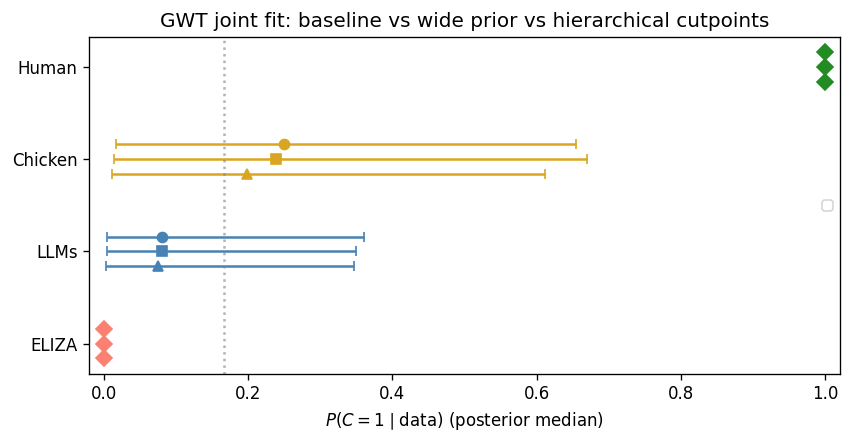

In [7]:
plot_c_comparison(results, Path("report_figures"))


## Stratified `pz1`-Based PPC

This is the main PPC from notebook 13 carried over into the new comparison.

/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:679: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.96) if title else None)


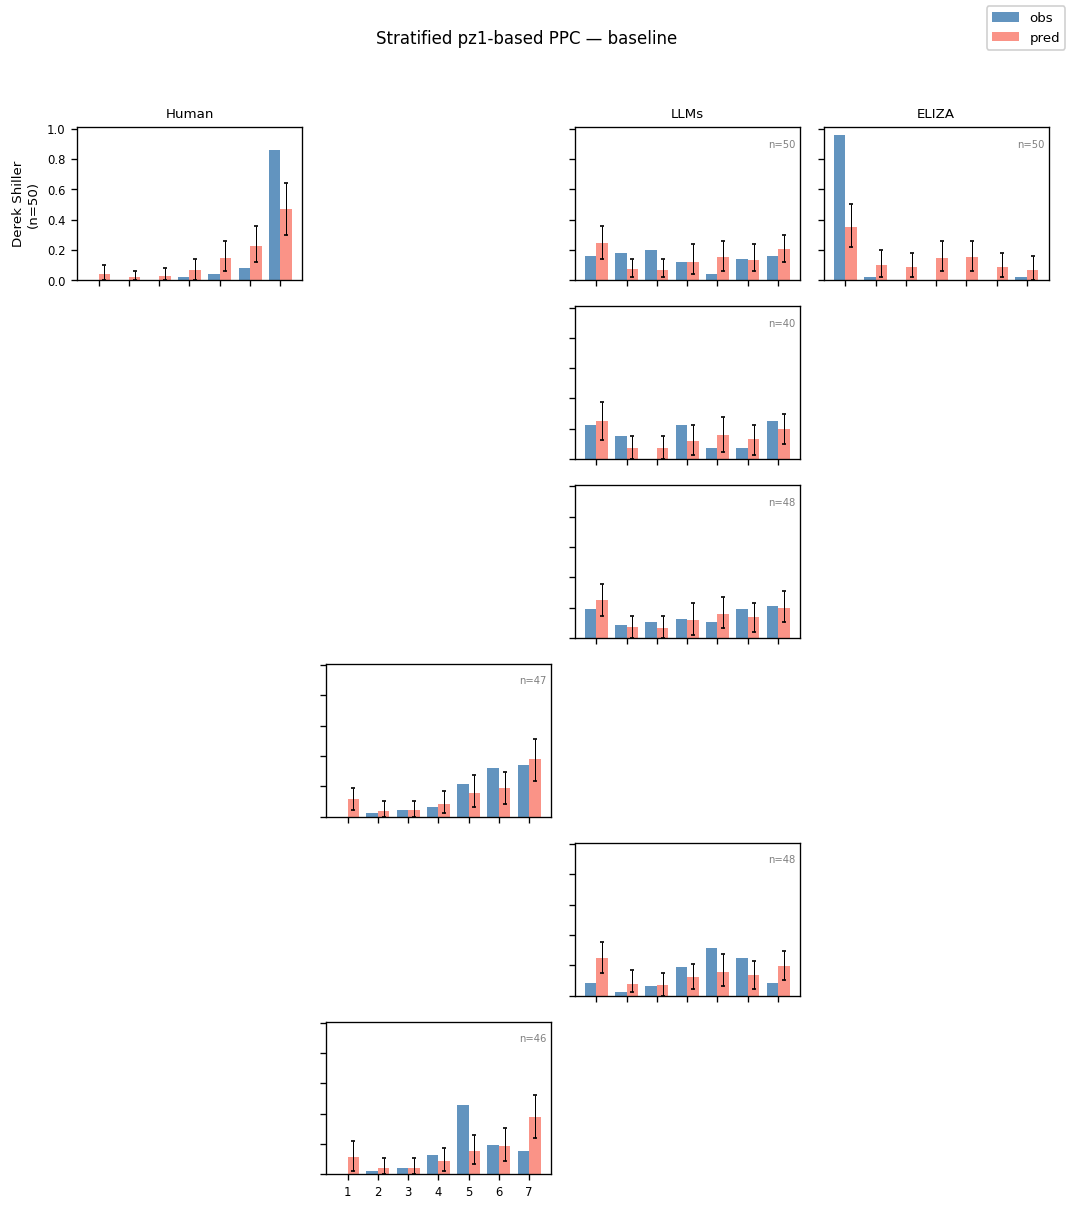

/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:679: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.96) if title else None)


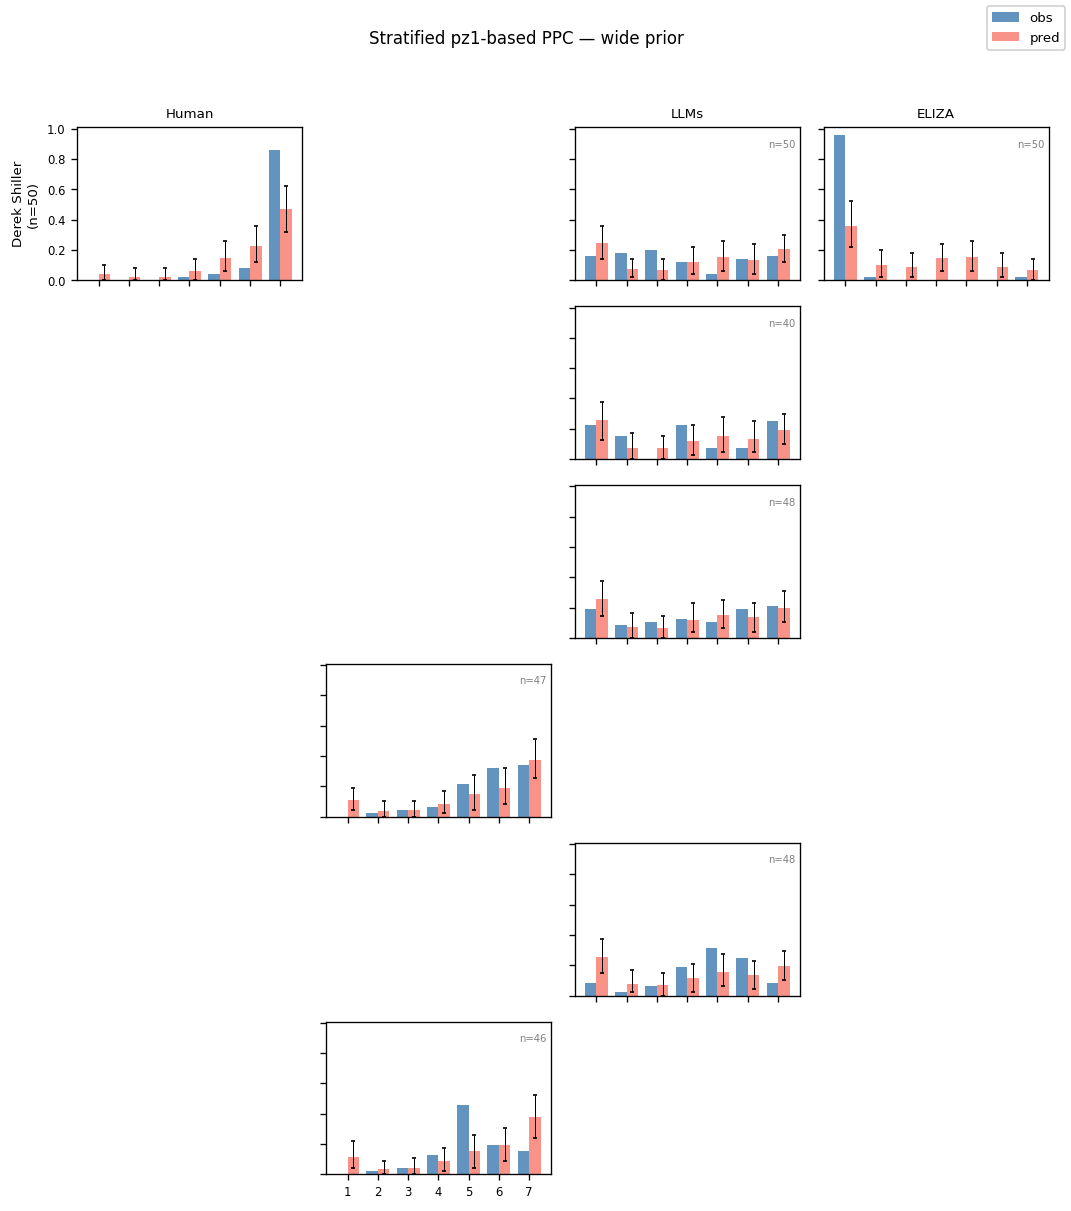

/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:679: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.96) if title else None)


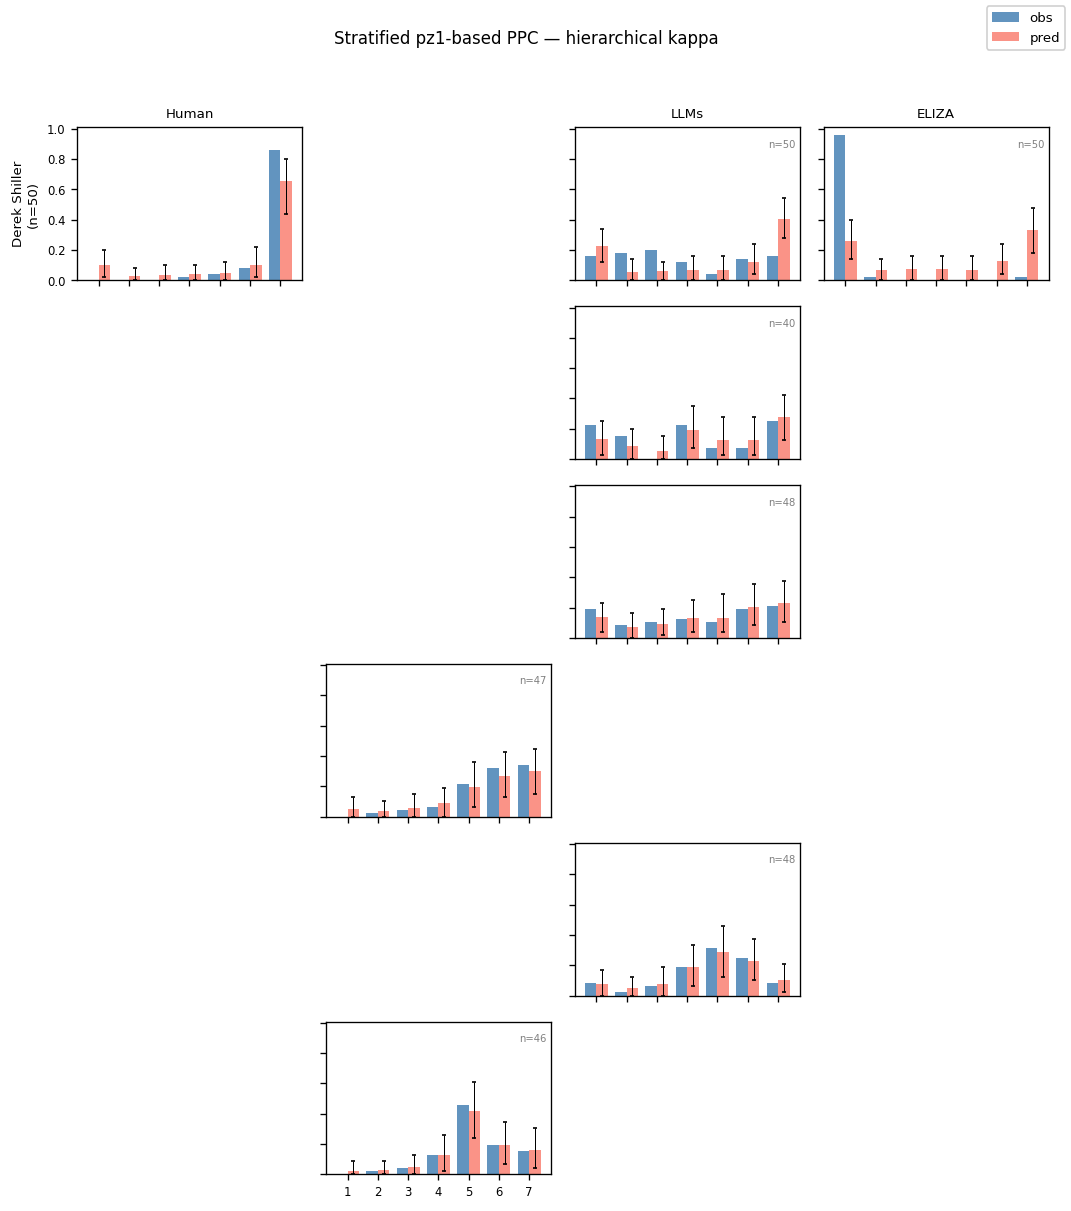

In [8]:
plot_stratified_ppc_suite(
    results,
    key="ppc_strat",
    title_prefix="Stratified pz1-based PPC",
    save_dir=Path("report_figures"),
)


## Stratified Tree-Implied PPC

This is the sidecar diagnostic added for this branch. It is useful for checking whether the tree-implied predictive already struggles before the extra local indicator update.

/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:679: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.96) if title else None)


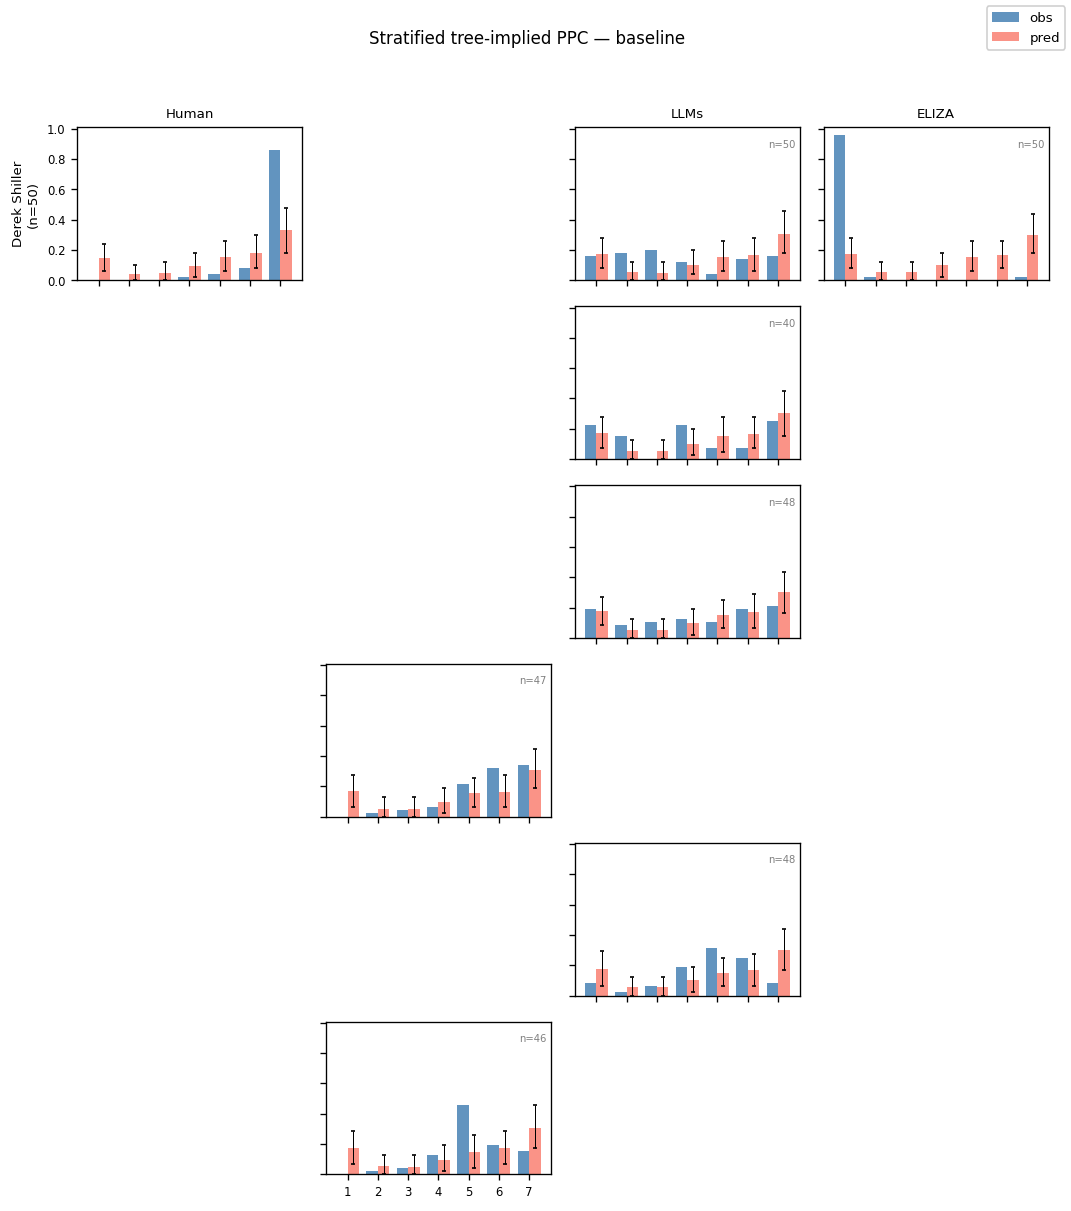

/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:679: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.96) if title else None)


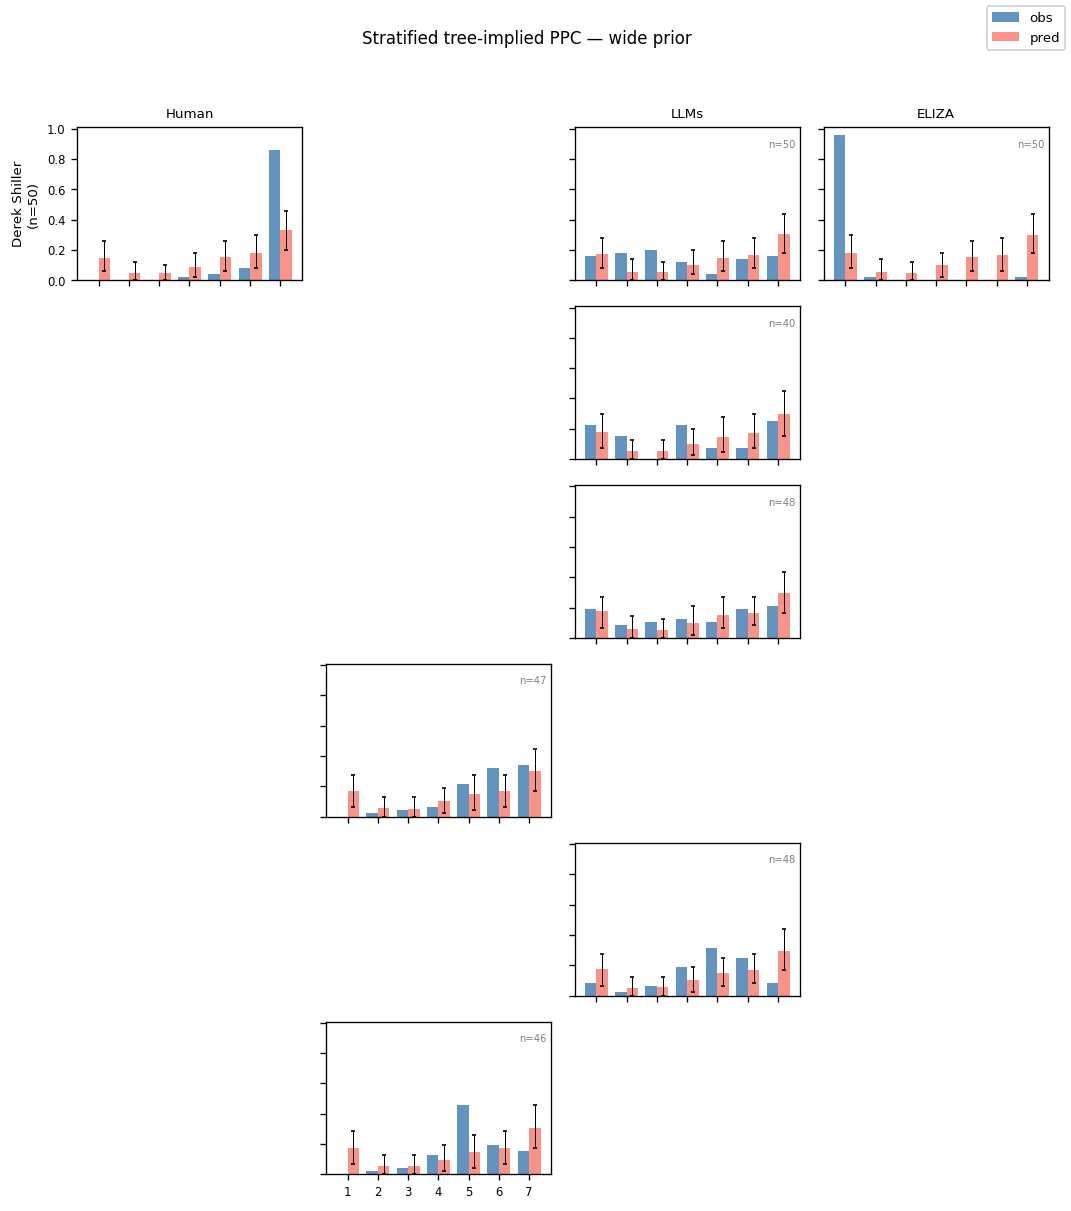

/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:679: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.96) if title else None)


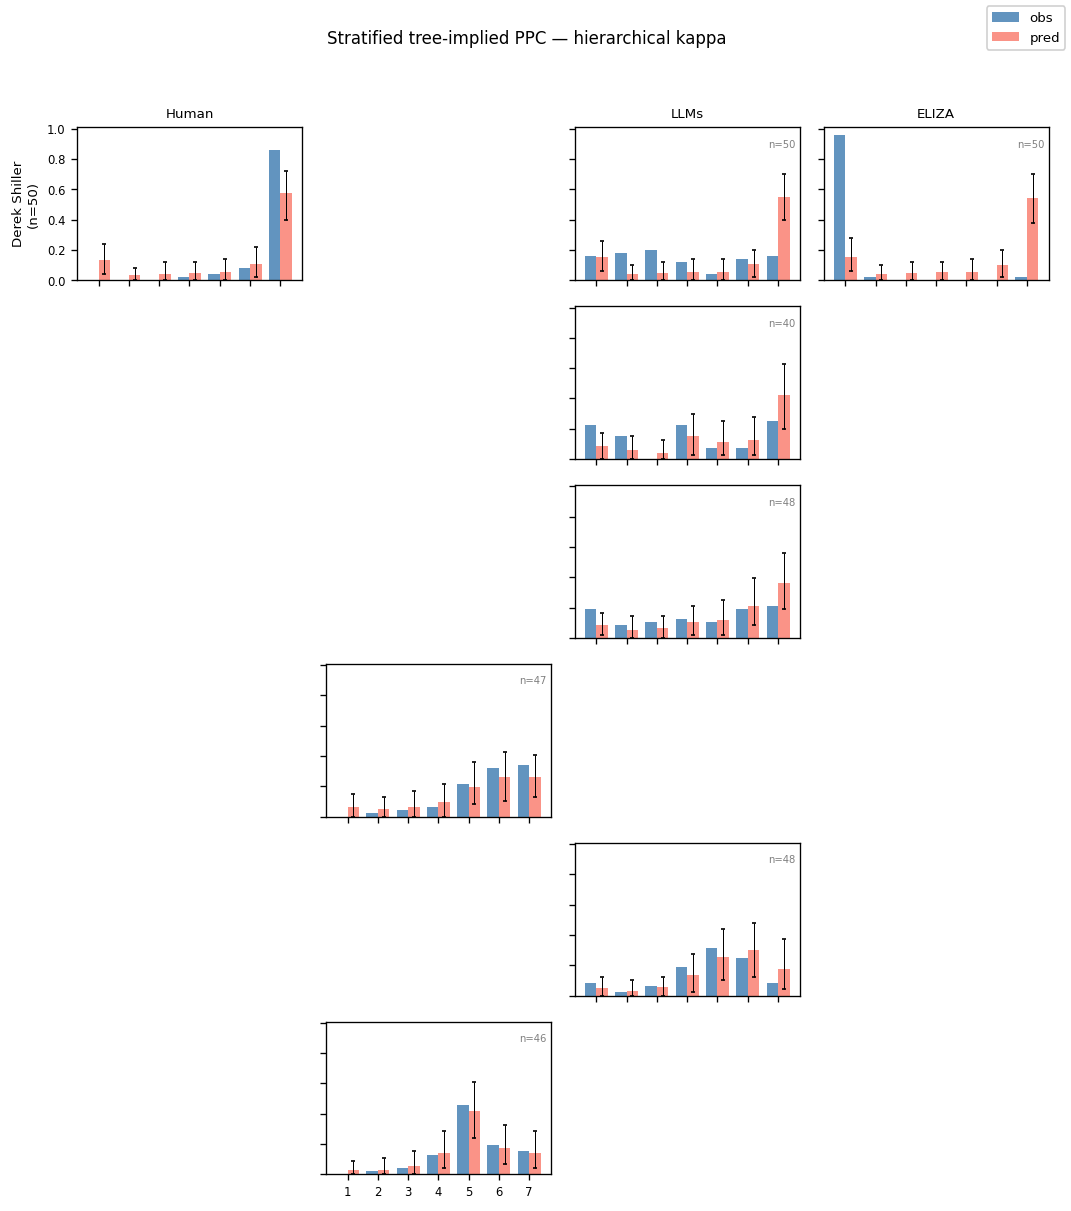

In [9]:
plot_stratified_ppc_suite(
    results,
    key="tree_implied_ppc_strat",
    title_prefix="Stratified tree-implied PPC",
    save_dir=Path("report_figures"),
)
